
Class distribution in GM evaluation set:
  Normal (Class 0): 113667 samples (71.43%)
  MITM (Class 1): 29 samples (0.02%)
  Ransomware (Class 2): 6970 samples (4.38%)
  Uploading (Class 3): 8547 samples (5.37%)
  DDoS_HTTP (Class 4): 24000 samples (15.08%)
  Port_Scanning (Class 5): 5927 samples (3.72%)
  Total GM evaluation samples: 159140

Creating non-IID client shards from remaining 1432252 samples...

Class distribution across clients:

Client 1:
  Normal (Class 0): 173526 samples (44.72%)
  MITM (Class 1): 64 samples (0.02%)
  Ransomware (Class 2): 7674 samples (1.98%)
  Uploading (Class 3): 25079 samples (6.46%)
  DDoS_HTTP (Class 4): 181583 samples (46.79%)
  Port_Scanning (Class 5): 145 samples (0.04%)
  Total samples: 388071

Client 2:
  Normal (Class 0): 815168 samples (96.12%)
  MITM (Class 1): 10 samples (0.00%)
  Ransomware (Class 2): 15459 samples (1.82%)
  Uploading (Class 3): 4815 samples (0.57%)
  DDoS_HTTP (Class 4): 4993 samples (0.59%)
  Port_Scanning (Class 5): 7

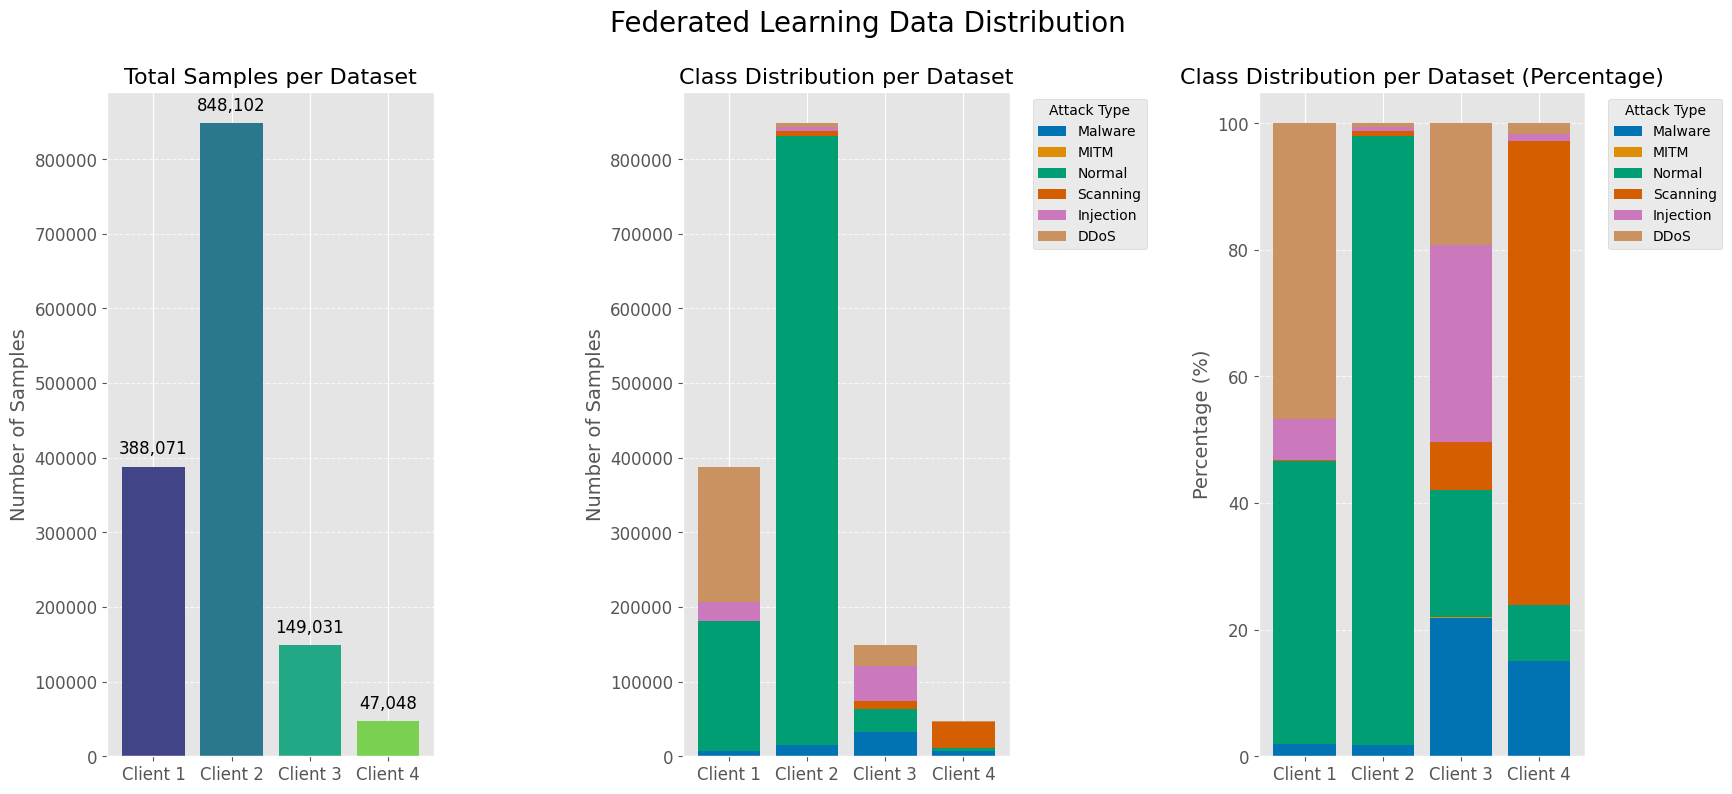


Visualization created and saved as 'federated_data_distribution_clients_only.png'

Data preparation complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('C:\\Users\\DELL\\OneDrive - King Abdullaziz University\\Desktop\\merged_clients_IoTEDGE.csv')

# Data validation before mapping - check for missing values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} missing values in Attack_type column")
    print("Fixing: Removing rows with missing Attack_type values")
    df = df.dropna(subset=['Attack_type'])

# Map attack types to numeric values as you've done
attacks = {
    'Normal': 0, 'MITM': 1, 'Uploading': 3, 'Ransomware': 2, 'SQL_injection': 3,
    'DDoS_HTTP': 4, 'DDoS_TCP': 4, 'Password': 2, 'Port_Scanning': 5,
    'Vulnerability_scanner': 5, 'Backdoor': 2, 'XSS': 3, 'Fingerprinting': 5,
    'DDoS_UDP': 4, 'DDoS_ICMP': 4
}

# Convert string attack types to numeric values
df['Attack_type'] = df['Attack_type'].map(attacks)

# Validate that mapping worked correctly - remove any rows with NaN values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} rows with unknown attack types")
    print("Fixing: Removing rows with unknown attack types")
    df = df.dropna(subset=['Attack_type'])

# Convert Attack_type to int32 (TensorFlow-friendly)
df['Attack_type'] = df['Attack_type'].astype(np.int32)

# Prepare features and target
Y = df['Attack_type']
X = df.drop(columns=['Attack_type', 'Attack_label'])

# STEP 1: First, extract an IID portion for global model evaluation

# Define the proportion of data to use for GM evaluation (e.g., 10%)
GM_EVAL_PROPORTION = 0.10

# Stratified sampling to ensure all classes are represented
X_remaining, X_gm_eval, Y_remaining, Y_gm_eval = train_test_split(
    X, Y, test_size=GM_EVAL_PROPORTION, stratify=Y, random_state=42
)

# Print class distribution in the GM evaluation set
gm_class_counts = Y_gm_eval.value_counts().sort_index()
print("\nClass distribution in GM evaluation set:")
for class_label, count in gm_class_counts.items():
    percentage = (count / len(Y_gm_eval)) * 100
    attack_name = [k for k, v in attacks.items() if v == class_label][0]
    print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
print(f"  Total GM evaluation samples: {len(Y_gm_eval)}")

# Create dataframe for GM evaluation
gm_eval_data = pd.concat([X_gm_eval.reset_index(drop=True), 
                          Y_gm_eval.reset_index(drop=True).rename("Attack_type")], axis=1)

# Save GM evaluation dataset
gm_eval_data.to_csv('iid_shard_GM.csv', index=False)

# STEP 2: Now create non-IID client shards from the remaining data
print(f"\nCreating non-IID client shards from remaining {len(Y_remaining)} samples...")

# Function to implement Quantity Skew for non-IID data distribution
def create_quantity_skew(X, Y, num_clients=4, alpha=0.5, min_samples_per_class=5):
    """
    Create a non-IID distribution with Quantity Skew among clients.
    
    Parameters:
    - X: Features dataframe
    - Y: Target series
    - num_clients: Number of clients for federated learning
    - alpha: Dirichlet distribution parameter (lower alpha = more skew)
    - min_samples_per_class: Minimum samples of each class per client
    
    Returns:
    - List of client datasets (X_client, Y_client) for each client
    """
    # Get unique classes
    classes = sorted(Y.unique())
    num_classes = len(classes)
    
    # Create class indices for easier manipulation
    class_indices = [np.where(Y == i)[0] for i in classes]
    
    # Reserve min_samples_per_class samples from each class for each client
    reserved_indices = [[] for _ in range(num_clients)]
    remaining_indices = [[] for _ in range(num_classes)]
    
    for c, class_idx in enumerate(class_indices):
        # Shuffle indices for randomness
        np.random.shuffle(class_idx)
        
        # Reserve samples for each client
        for client_id in range(num_clients):
            if len(class_idx) >= (client_id + 1) * min_samples_per_class:
                client_reserved = class_idx[client_id * min_samples_per_class:(client_id + 1) * min_samples_per_class]
                reserved_indices[client_id].extend(client_reserved)
            else:
                # If not enough samples, take what's available
                available = len(class_idx) - client_id * min_samples_per_class
                if available > 0:
                    client_reserved = class_idx[client_id * min_samples_per_class:]
                    reserved_indices[client_id].extend(client_reserved)
        
        # Remaining indices after reservation
        reserved_count = min(len(class_idx), num_clients * min_samples_per_class)
        remaining_indices[c] = class_idx[reserved_count:].tolist()
    
    # Generate proportions using Dirichlet distribution
    np.random.seed(42)  # For reproducibility
    proportions = np.random.dirichlet(np.repeat(alpha, num_clients), size=num_classes)
    
    # Initialize client data with reserved indices
    client_data = reserved_indices.copy()
    
    # Distribute remaining data according to proportions
    for c, rem_idx in enumerate(remaining_indices):
        if len(rem_idx) == 0:
            continue
            
        # Calculate sample counts for each client for this class
        client_sample_counts = (proportions[c] * len(rem_idx)).astype(int)
        
        # Adjust the last count to ensure all samples are used
        client_sample_counts[-1] = len(rem_idx) - np.sum(client_sample_counts[:-1])
        
        # Assign indices to clients
        start_idx = 0
        for client_id, count in enumerate(client_sample_counts):
            if count > 0:
                client_data[client_id].extend(rem_idx[start_idx:start_idx + count])
                start_idx += count
    
    # Create client datasets
    client_datasets = []
    for client_id in range(num_clients):
        indices = client_data[client_id]
        X_client = X.iloc[indices].reset_index(drop=True)
        Y_client = Y.iloc[indices].reset_index(drop=True)
        
        client_datasets.append((X_client, Y_client))
    
    return client_datasets

# Create non-IID datasets with Quantity Skew
client_datasets = create_quantity_skew(X_remaining, Y_remaining, num_clients=4, 
                                       alpha=0.5, min_samples_per_class=10)

# Analyze the distribution of classes across clients
print("\nClass distribution across clients:")
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    class_counts = Y_client.value_counts().sort_index()
    total = len(Y_client)
    print(f"\nClient {client_id+1}:")
    for class_label, count in class_counts.items():
        percentage = (count / total) * 100
        attack_name = [k for k, v in attacks.items() if v == class_label][0]
        print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
    print(f"  Total samples: {total}")

# Save client datasets with the specified naming convention
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    # Combine features and target for saving
    client_data = pd.concat([X_client, Y_client.rename("Attack_type")], axis=1)
    
    # Final validation check before saving
    # 1. Ensure Attack_type is int32
    client_data['Attack_type'] = client_data['Attack_type'].astype(np.int32)
    
    # 2. Verify all values are within expected range (0-5)
    invalid_mask = ~client_data['Attack_type'].between(0, 5)
    if invalid_mask.any():
        print(f"WARNING: Found {invalid_mask.sum()} invalid Attack_type values in Client {client_id+1}")
        print("Fixing: Removing rows with invalid Attack_type values")
        client_data = client_data[~invalid_mask]
    
    # 3. Check that all attack types are present
    unique_classes = client_data['Attack_type'].unique()
    if len(unique_classes) < 6:
        missing_classes = set(range(6)) - set(unique_classes)
        print(f"WARNING: Client {client_id+1} is missing attack types: {missing_classes}")
        print("Please consider increasing min_samples_per_class or checking your data distribution")
    
    # Save to CSV with shard_N.csv naming convention
    client_data.to_csv(f'shard_{client_id+1}.csv', index=False)
    
    # Print class distribution for verification
    class_counts = client_data['Attack_type'].value_counts().sort_index()
    total = len(client_data)
    print(f"\nClient {client_id+1} final dataset:")
    for class_label, count in class_counts.items():
        percentage = (count / total) * 100
        attack_name = [k for k, v in attacks.items() if v == class_label][0]
        print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
    print(f"  Total samples: {total}")

print("\nIID GM evaluation dataset and non-IID client datasets have been created and saved in folder.")
print("- Global model evaluation dataset: iid_shard_GM.csv")
print("- Client shards: shard_1.csv, shard_2.csv, etc.")

# Set up the plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")
plt.figure(figsize=(18, 8))

# Get client totals and attack types
clients = [f'Client {i+1}' for i in range(len(client_datasets))]
client_totals = [len(client_datasets[i][1]) for i in range(len(client_datasets))]
attack_class_names = {
    0: 'Normal',
    1: 'MITM',
    2: 'Malware',
    3: 'Injection',
    4: 'DDoS',
    5: 'Scanning'
}


# Create a dictionary for class distribution per client
class_distribution = {}

# Add client data
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    client_name = f'Client {client_id+1}'
    class_counts = Y_client.value_counts().sort_index().to_dict()
    class_distribution[client_name] = {attack_class_names.get(class_label, f'Class {class_label}'): count 
                                     for class_label, count in class_counts.items()}

# Create a list of unique attack names
unique_attack_names = list(set([attack_class_names.get(i, f'Class {i}') for i in range(6)]))

# 1. Bar chart showing total samples per client
plt.subplot(1, 3, 1)
plt.bar(clients, client_totals, color=sns.color_palette("viridis", len(clients)))
plt.title('Total Samples per Dataset', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add the values on top of each bar
for i, total in enumerate(client_totals):
    plt.text(i, total + max(client_totals)*0.02, f'{total:,}', ha='center', fontsize=12)

# 2. Stacked bar chart showing class distribution
data_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        data_matrix[i, j] = value

plt.subplot(1, 3, 2)
bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, data_matrix[:, j], bottom=bottom, label=attack)
    bottom += data_matrix[:, j]

plt.title('Class Distribution per Dataset', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 3. Percentage stacked bar chart
plt.subplot(1, 3, 3)
percentage_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    client_total = client_totals[i]
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        percentage_matrix[i, j] = (value / client_total) * 100

bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, percentage_matrix[:, j], bottom=bottom, label=attack)
    bottom += percentage_matrix[:, j]

plt.title('Class Distribution per Dataset (Percentage)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout(pad=3.0)
plt.suptitle('Federated Learning Data Distribution', fontsize=20, y=1.02)

# Save the figure
plt.savefig('federated_data_distribution_clients_only.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created and saved as 'federated_data_distribution_clients_only.png'")
print("\nData preparation complete!")

# 8 clients data distribution


Class distribution in GM evaluation set:
  Normal (Class 0): 113667 samples (71.43%)
  MITM (Class 1): 29 samples (0.02%)
  Ransomware (Class 2): 6970 samples (4.38%)
  Uploading (Class 3): 8547 samples (5.37%)
  DDoS_HTTP (Class 4): 24000 samples (15.08%)
  Port_Scanning (Class 5): 5927 samples (3.72%)
  Total GM evaluation samples: 159140

Creating non-IID client shards from remaining 1432252 samples for 8 clients...

Initial distribution created...
Target range: 100,000 - 200,000 samples per client
Client 1: 76,724 samples -> Kept as-is
Client 2: 482,976 samples -> Limited to 200,000 samples, 282,976 overflow
Client 3: 249,561 samples -> Limited to 200,000 samples, 49,561 overflow
Client 4: 188,393 samples -> Kept as-is
Client 5: 60,401 samples -> Kept as-is
Client 6: 36,815 samples -> Kept as-is
Client 7: 54,800 samples -> Kept as-is
Client 8: 282,582 samples -> Limited to 200,000 samples, 82,582 overflow

Total overflow data: 415,119 samples
Client 1: Adding 23,276 samples from o

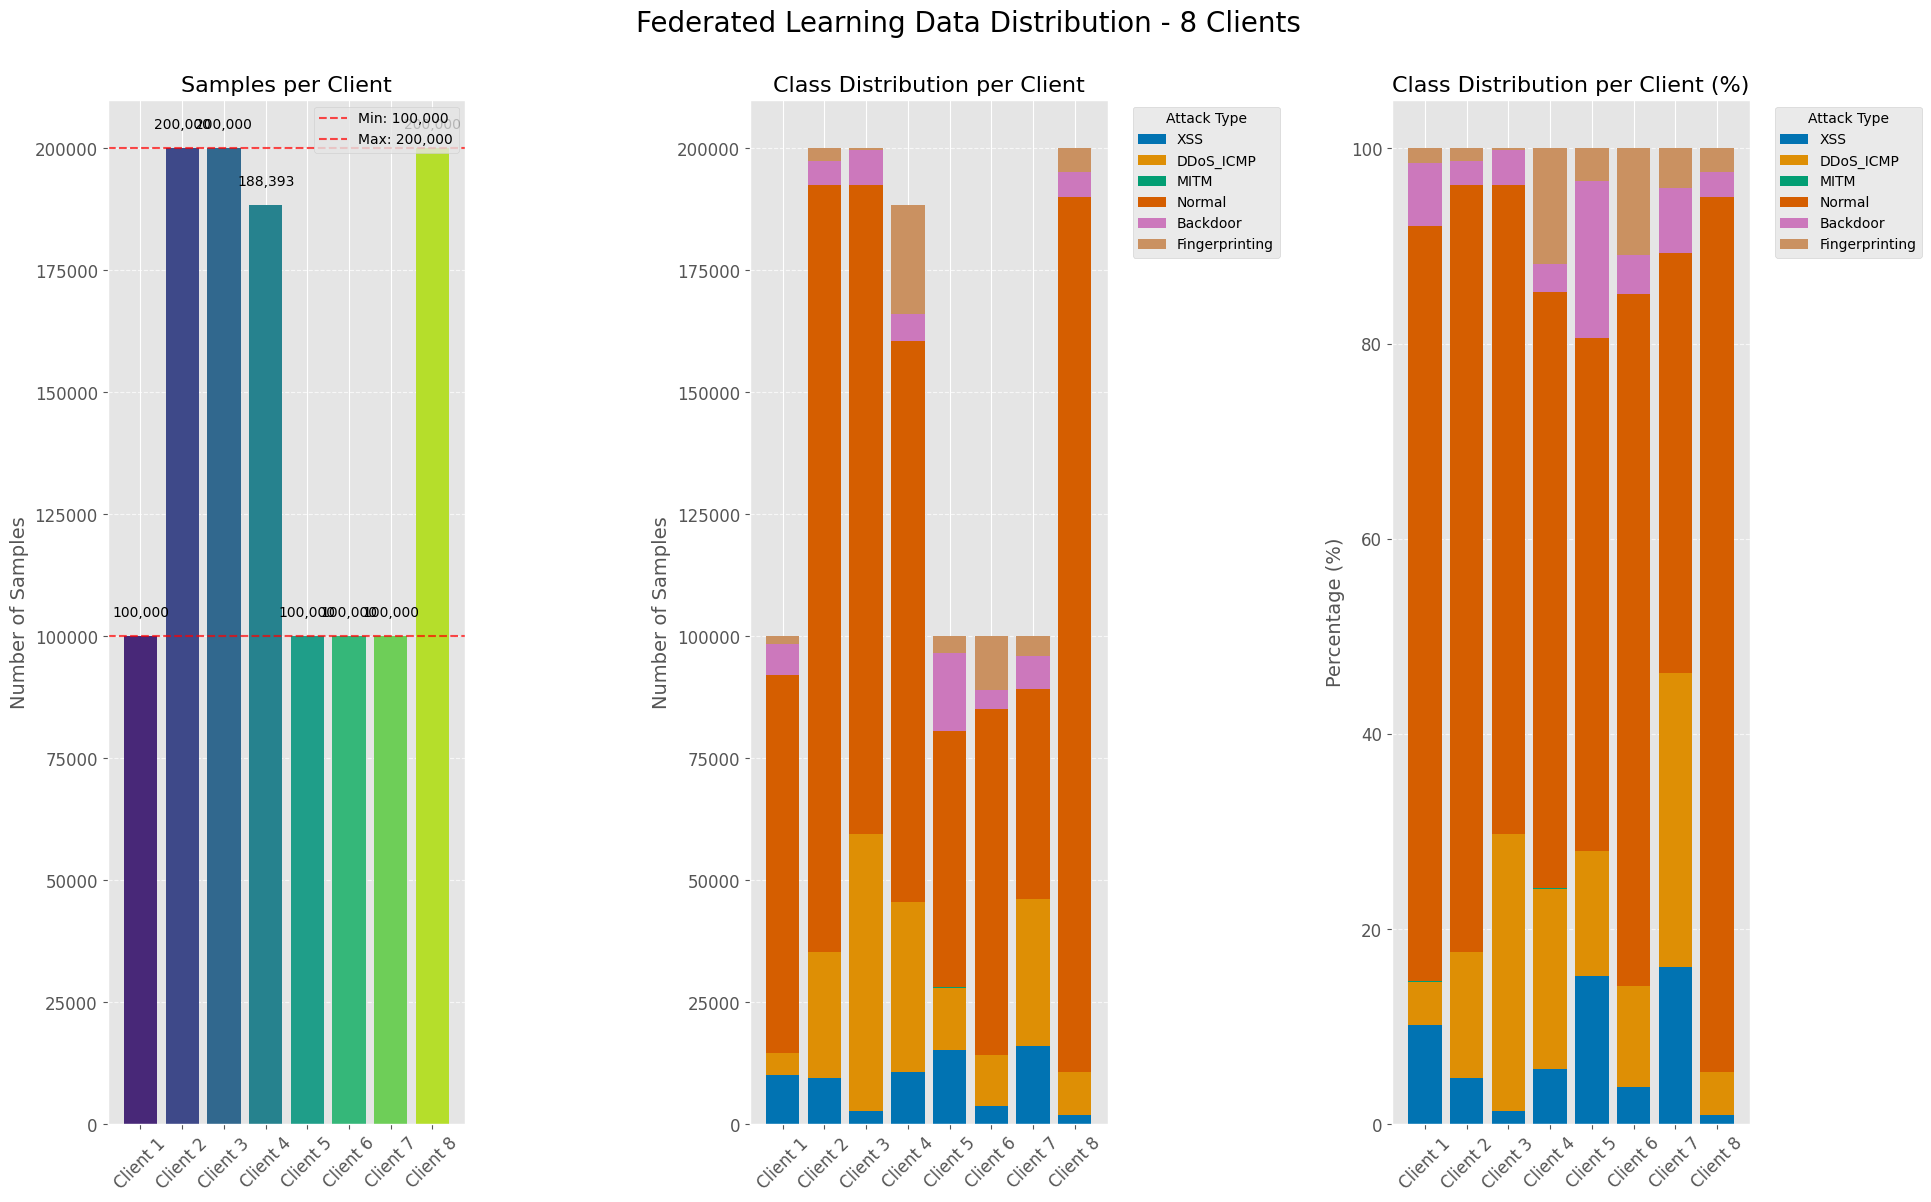


Visualization created and saved as 'federated_data_distribution_8_clients.png'

Data preparation for 8 clients complete!

This should significantly improve your global model performance!


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('C:\\Users\\DELL\\OneDrive - King Abdullaziz University\\Desktop\\merged_clients_IoTEDGE.csv')


# Data validation before mapping - check for missing values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} missing values in Attack_type column")
    print("Fixing: Removing rows with missing Attack_type values")
    df = df.dropna(subset=['Attack_type'])

# Map attack types to numeric values as you've done
attacks = {
    'Normal': 0, 'MITM': 1, 'Uploading': 3, 'Ransomware': 2, 'SQL_injection': 3,
    'DDoS_HTTP': 4, 'DDoS_TCP': 4, 'Password': 2, 'Port_Scanning': 5,
    'Vulnerability_scanner': 5, 'Backdoor': 2, 'XSS': 3, 'Fingerprinting': 5,
    'DDoS_UDP': 4, 'DDoS_ICMP': 4
}

# Convert string attack types to numeric values
df['Attack_type'] = df['Attack_type'].map(attacks)

# Validate that mapping worked correctly - remove any rows with NaN values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} rows with unknown attack types")
    print("Fixing: Removing rows with unknown attack types")
    df = df.dropna(subset=['Attack_type'])

# Convert Attack_type to int32 (TensorFlow-friendly)
df['Attack_type'] = df['Attack_type'].astype(np.int32)

# Prepare features and target
Y = df['Attack_type']
X = df.drop(columns=['Attack_type', 'Attack_label'])

# STEP 1: First, extract an IID portion for global model evaluation
# Keep the same GM evaluation proportion to maintain consistency
GM_EVAL_PROPORTION = 0.10

# Stratified sampling to ensure all classes are represented
X_remaining, X_gm_eval, Y_remaining, Y_gm_eval = train_test_split(
    X, Y, test_size=GM_EVAL_PROPORTION, stratify=Y, random_state=42
)

# Print class distribution in the GM evaluation set
gm_class_counts = Y_gm_eval.value_counts().sort_index()
print("\nClass distribution in GM evaluation set:")
for class_label, count in gm_class_counts.items():
    percentage = (count / len(Y_gm_eval)) * 100
    attack_name = [k for k, v in attacks.items() if v == class_label][0]
    print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
print(f"  Total GM evaluation samples: {len(Y_gm_eval)}")

# Create dataframe for GM evaluation (keep same filename for compatibility)
gm_eval_data = pd.concat([X_gm_eval.reset_index(drop=True), 
                          Y_gm_eval.reset_index(drop=True).rename("Attack_type")], axis=1)

# Save GM evaluation dataset
gm_eval_data.to_csv('iid_shard_GM.csv', index=False)

# STEP 2: Now create non-IID client shards from the remaining data
NUM_CLIENTS = 8
print(f"\nCreating non-IID client shards from remaining {len(Y_remaining)} samples for {NUM_CLIENTS} clients...")

# Function to implement Quantity Skew for non-IID data distribution
def create_quantity_skew(X, Y, num_clients=8, alpha=1.0, min_samples_per_class=20):
    """
    Create a non-IID distribution with Quantity Skew among clients.
    
    Parameters:
    - X: Features dataframe
    - Y: Target series
    - num_clients: Number of clients for federated learning (now 8)
    - alpha: Dirichlet distribution parameter (lower alpha = more skew)
    - min_samples_per_class: Minimum samples of each class per client
    
    Returns:
    - List of client datasets (X_client, Y_client) for each client
    """
    # Get unique classes
    classes = sorted(Y.unique())
    num_classes = len(classes)
    
    # Create class indices for easier manipulation
    class_indices = [np.where(Y == i)[0] for i in classes]
    
    # Reserve min_samples_per_class samples from each class for each client
    reserved_indices = [[] for _ in range(num_clients)]
    remaining_indices = [[] for _ in range(num_classes)]
    
    for c, class_idx in enumerate(class_indices):
        # Shuffle indices for randomness
        np.random.shuffle(class_idx)
        
        # Reserve samples for each client
        for client_id in range(num_clients):
            if len(class_idx) >= (client_id + 1) * min_samples_per_class:
                client_reserved = class_idx[client_id * min_samples_per_class:(client_id + 1) * min_samples_per_class]
                reserved_indices[client_id].extend(client_reserved)
            else:
                # If not enough samples, take what's available
                available = len(class_idx) - client_id * min_samples_per_class
                if available > 0:
                    client_reserved = class_idx[client_id * min_samples_per_class:]
                    reserved_indices[client_id].extend(client_reserved)
        
        # Remaining indices after reservation
        reserved_count = min(len(class_idx), num_clients * min_samples_per_class)
        remaining_indices[c] = class_idx[reserved_count:].tolist()
    
    # Generate proportions using Dirichlet distribution
    # IMPORTANT: Keep the same random seed for reproducibility
    np.random.seed(42)  
    proportions = np.random.dirichlet(np.repeat(alpha, num_clients), size=num_classes)
    
    # Initialize client data with reserved indices
    client_data = reserved_indices.copy()
    
    # Distribute remaining data according to proportions
    for c, rem_idx in enumerate(remaining_indices):
        if len(rem_idx) == 0:
            continue
            
        # Calculate sample counts for each client for this class
        client_sample_counts = (proportions[c] * len(rem_idx)).astype(int)
        
        # Adjust the last count to ensure all samples are used
        client_sample_counts[-1] = len(rem_idx) - np.sum(client_sample_counts[:-1])
        
        # Assign indices to clients
        start_idx = 0
        for client_id, count in enumerate(client_sample_counts):
            if count > 0:
                client_data[client_id].extend(rem_idx[start_idx:start_idx + count])
                start_idx += count
    
    # Create client datasets
    client_datasets = []
    for client_id in range(num_clients):
        indices = client_data[client_id]
        X_client = X.iloc[indices].reset_index(drop=True)
        Y_client = Y.iloc[indices].reset_index(drop=True)
        
        client_datasets.append((X_client, Y_client))
    
    return client_datasets

# Create initial non-IID datasets with better parameters
client_datasets = create_quantity_skew(
    X_remaining, Y_remaining, 
    num_clients=NUM_CLIENTS, 
    alpha=1.0,  # More distribution
    min_samples_per_class=20  # Better representation
)

print("\nInitial distribution created...")

# MANUAL TO SOLVE THE PROBLEM
MAX_SAMPLES_PER_CLIENT = 200000
MIN_SAMPLES_PER_CLIENT = 100000

init_datasets = []
overflow_data = {'X': [], 'Y': []}

print(f"Target range: {MIN_SAMPLES_PER_CLIENT:,} - {MAX_SAMPLES_PER_CLIENT:,} samples per client")

# First pass: collect overflow data from large clients
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    current_samples = len(Y_client)
    print(f"Client {client_id+1}: {current_samples:,} samples", end="")
    
    if current_samples > MAX_SAMPLES_PER_CLIENT:
        # Keep MAX_SAMPLES_PER_CLIENT samples using stratified sampling to maintain class distribution
        from sklearn.model_selection import train_test_split
        
        # Calculate what proportion to keep
        keep_ratio = MAX_SAMPLES_PER_CLIENT / current_samples
        
        # Stratified sampling to maintain class distribution
        X_keep, X_overflow, Y_keep, Y_overflow = train_test_split(
            X_client, Y_client, 
            train_size=keep_ratio, 
            stratify=Y_client,
            random_state=42 + client_id
        )
        
        # Store overflow
        overflow_data['X'].append(X_overflow)
        overflow_data['Y'].append(Y_overflow)
        
        # Keep limited samples
        init_datasets.append((X_keep.reset_index(drop=True), Y_keep.reset_index(drop=True)))
        print(f" -> Limited to {len(Y_keep):,} samples, {len(Y_overflow):,} overflow")
    else:
        init_datasets.append((X_client, Y_client))
        print(f" -> Kept as-is")

# Combine all overflow data
if overflow_data['X']:
    overflow_X = pd.concat(overflow_data['X']).reset_index(drop=True)
    overflow_Y = pd.concat(overflow_data['Y']).reset_index(drop=True)
    print(f"\nTotal overflow data: {len(overflow_Y):,} samples")
else:
    overflow_X = pd.DataFrame()
    overflow_Y = pd.Series(dtype='int32')

# Second pass: distribute overflow to small clients
for client_id, (X_client, Y_client) in enumerate(init_datasets):
    current_samples = len(Y_client)
    
    if current_samples < MIN_SAMPLES_PER_CLIENT and len(overflow_Y) > 0:
        needed = MIN_SAMPLES_PER_CLIENT - current_samples
        available = len(overflow_Y)
        to_add = min(needed, available)
        
        print(f"Client {client_id+1}: Adding {to_add:,} samples from overflow")
        
        # Add overflow data (taking first 'to_add' samples)
        X_client = pd.concat([X_client, overflow_X[:to_add]]).reset_index(drop=True)
        Y_client = pd.concat([Y_client, overflow_Y[:to_add]]).reset_index(drop=True)
        
        # Remove used data from overflow
        overflow_X = overflow_X[to_add:].reset_index(drop=True)
        overflow_Y = overflow_Y[to_add:].reset_index(drop=True)
        
        init_datasets[client_id] = (X_client, Y_client)

# Update client_datasets 
client_datasets = init_datasets

# Analyze the distribution of classes across clients
print("\n" + "="*60)
print("Class distribution across clients:")
print("="*60)
total_samples_distributed = 0
sample_counts = []

for client_id, (X_client, Y_client) in enumerate(client_datasets):
    class_counts = Y_client.value_counts().sort_index()
    total = len(Y_client)
    total_samples_distributed += total
    sample_counts.append(total)
    
    print(f"\nClient {client_id+1}:")
    for class_label, count in class_counts.items():
        percentage = (count / total) * 100
        attack_name = [k for k, v in attacks.items() if v == class_label][0]
        print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
    print(f"  Total samples: {total:,}")

print(f"\nTotal samples distributed across all {NUM_CLIENTS} clients: {total_samples_distributed:,}")
print(f"Original remaining samples: {len(Y_remaining):,}")
print(f"GM evaluation samples: {len(Y_gm_eval):,}")

# Print statistics
min_samples = min(sample_counts)
max_samples = max(sample_counts)
ratio = max_samples / min_samples if min_samples > 0 else float('inf')
print(f"\nStatistics:")
print(f"  Minimum samples per client: {min_samples:,}")
print(f"  Maximum samples per client: {max_samples:,}")
print(f"  Average samples per client: {total_samples_distributed / NUM_CLIENTS:,.0f}")


# Save client datasets with the specified naming convention
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    # Combine features and target for saving
    client_data = pd.concat([X_client, Y_client.rename("Attack_type")], axis=1)
    
    # Final validation check before saving
    # 1. Ensure Attack_type is int32
    client_data['Attack_type'] = client_data['Attack_type'].astype(np.int32)
    
    # 2. Verify all values are within expected range (0-5)
    invalid_mask = ~client_data['Attack_type'].between(0, 5)
    if invalid_mask.any():
        print(f"WARNING: Found {invalid_mask.sum()} invalid Attack_type values in Client {client_id+1}")
        print("Fixing: Removing rows with invalid Attack_type values")
        client_data = client_data[~invalid_mask]
    
    # 3. Check that all attack types are present
    unique_classes = client_data['Attack_type'].unique()
    if len(unique_classes) < 6:
        missing_classes = set(range(6)) - set(unique_classes)
        print(f"INFO: Client {client_id+1} is missing attack types: {missing_classes}")
        print("This is expected for non-IID distribution - clients specialize in certain attack types")
    
    # Save to CSV with shard_N.csv naming convention
    client_data.to_csv(f'shard_{client_id+1}.csv', index=False)

# Print summary statistics
print(f"\n{NUM_CLIENTS} non-IID client datasets have been created and saved.")
print("- Global model evaluation dataset: iid_shard_GM.csv")
print("- Client shards: shard_1.csv through shard_8.csv")

# VISUALIZATION: Modified for 8 clients
plt.style.use('ggplot')
sns.set_palette("colorblind")
plt.figure(figsize=(20, 12))

# Get client totals and attack types
clients = [f'Client {i+1}' for i in range(len(client_datasets))]
client_totals = [len(client_datasets[i][1]) for i in range(len(client_datasets))]
attack_class_names = {v: k for k, v in attacks.items()}

# Create a dictionary for class distribution per client
class_distribution = {}

# Add client data
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    client_name = f'Client {client_id+1}'
    class_counts = Y_client.value_counts().sort_index().to_dict()
    class_distribution[client_name] = {attack_class_names.get(class_label, f'Class {class_label}'): count 
                                     for class_label, count in class_counts.items()}

# Create a list of unique attack names
unique_attack_names = list(set([attack_class_names.get(i, f'Class {i}') for i in range(6)]))

# 1. Bar chart showing total samples per client
plt.subplot(1, 3, 1)
colors = sns.color_palette("viridis", len(clients))
bars = plt.bar(clients, client_totals, color=colors)
plt.title(f'Samples per Client', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add horizontal lines for target range
plt.axhline(y=MIN_SAMPLES_PER_CLIENT, color='red', linestyle='--', alpha=0.7, label=f'Min: {MIN_SAMPLES_PER_CLIENT:,}')
plt.axhline(y=MAX_SAMPLES_PER_CLIENT, color='red', linestyle='--', alpha=0.7, label=f'Max: {MAX_SAMPLES_PER_CLIENT:,}')
plt.legend()

# Add the values on top of each bar
for i, total in enumerate(client_totals):
    plt.text(i, total + max(client_totals)*0.02, f'{total:,}', ha='center', fontsize=10)

# 2. Stacked bar chart showing class distribution
data_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        data_matrix[i, j] = value

plt.subplot(1, 3, 2)
bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, data_matrix[:, j], bottom=bottom, label=attack)
    bottom += data_matrix[:, j]

plt.title('Class Distribution per Client', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# 3. Percentage stacked bar chart
plt.subplot(1, 3, 3)
percentage_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    client_total = client_totals[i]
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        percentage_matrix[i, j] = (value / client_total) * 100

bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, percentage_matrix[:, j], bottom=bottom, label=attack)
    bottom += percentage_matrix[:, j]

plt.title('Class Distribution per Client (%)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout(pad=3.0)
plt.suptitle('Federated Learning Data Distribution - 8 Clients', fontsize=20, y=1.02)

# Save the figure
plt.savefig('federated_data_distribution_8_clients.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created and saved as 'federated_data_distribution_8_clients.png'")
print("\nData preparation for 8 clients complete!")
print("\nThis should significantly improve your global model performance!")

# 16 clients data distribution


Class distribution in GM evaluation set:
  Normal (Class 0): 113667 samples (71.43%)
  MITM (Class 1): 29 samples (0.02%)
  Ransomware (Class 2): 6970 samples (4.38%)
  Uploading (Class 3): 8547 samples (5.37%)
  DDoS_HTTP (Class 4): 24000 samples (15.08%)
  Port_Scanning (Class 5): 5927 samples (3.72%)
  Total GM evaluation samples: 159140

Creating non-IID client shards from remaining 1432252 samples for 16 clients...
Total available data: 1,432,252
Target per client: 89,515
Calculated range: 53,709 - 125,321

Initial distribution created....
Target range: 53,709 - 125,321 samples per client
Client 1: 98,298 samples -> Kept as-is
Client 2: 78,395 samples -> Kept as-is
Client 3: 56,568 samples -> Kept as-is
Client 4: 67,072 samples -> Kept as-is
Client 5: 178,796 samples -> Limited to 125,321 samples, 53,475 overflow
Client 6: 150,590 samples -> Limited to 125,321 samples, 25,269 overflow
Client 7: 53,970 samples -> Kept as-is
Client 8: 109,523 samples -> Kept as-is
Client 9: 100,645

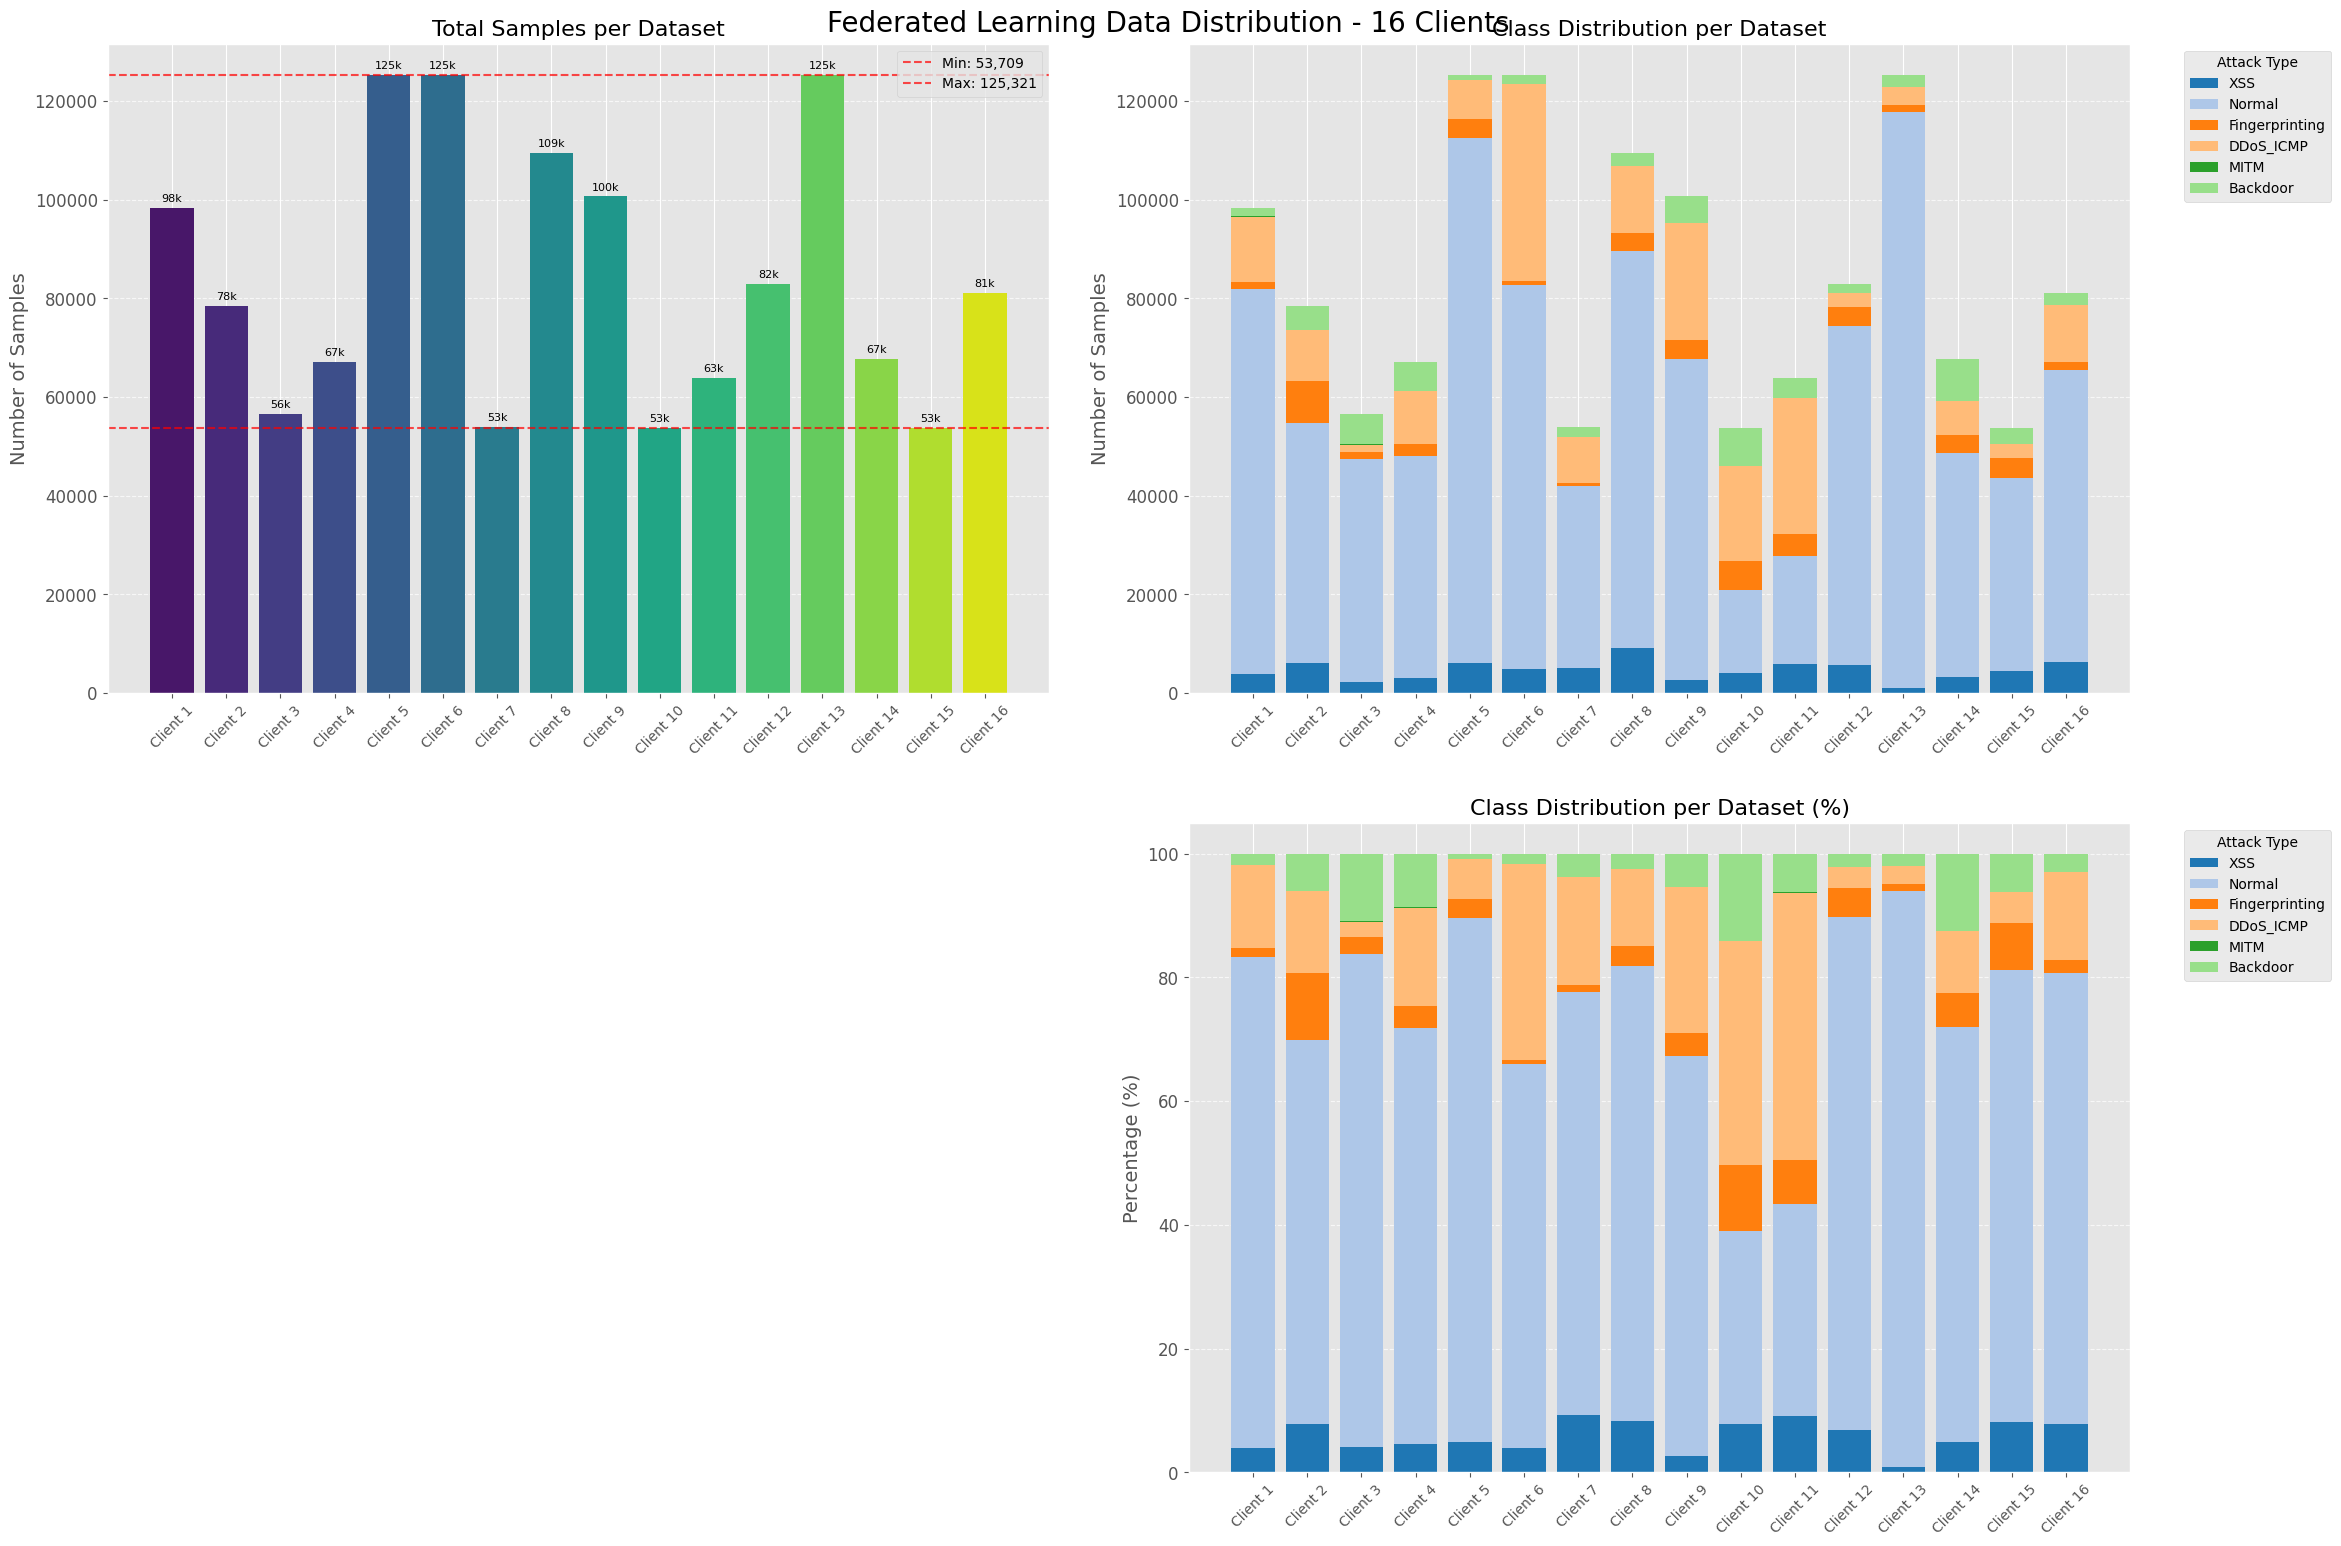


Visualization created and saved as 'federated_data_distribution_16_clients.png'

Data preparation for 16 clients complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('C:\\Users\\DELL\\OneDrive - King Abdullaziz University\\Desktop\\merged_clients_IoTEDGE.csv')

# Data validation before mapping - check for missing values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} missing values in Attack_type column")
    print("Fixing: Removing rows with missing Attack_type values")
    df = df.dropna(subset=['Attack_type'])

# Map attack types to numeric values as you've done
attacks = {
    'Normal': 0, 'MITM': 1, 'Uploading': 3, 'Ransomware': 2, 'SQL_injection': 3,
    'DDoS_HTTP': 4, 'DDoS_TCP': 4, 'Password': 2, 'Port_Scanning': 5,
    'Vulnerability_scanner': 5, 'Backdoor': 2, 'XSS': 3, 'Fingerprinting': 5,
    'DDoS_UDP': 4, 'DDoS_ICMP': 4
}

# Convert string attack types to numeric values
df['Attack_type'] = df['Attack_type'].map(attacks)

# Validate that mapping worked correctly - remove any rows with NaN values
if df['Attack_type'].isna().any():
    print(f"WARNING: Found {df['Attack_type'].isna().sum()} rows with unknown attack types")
    print("Fixing: Removing rows with unknown attack types")
    df = df.dropna(subset=['Attack_type'])

# Convert Attack_type to int32 (TensorFlow-friendly)
df['Attack_type'] = df['Attack_type'].astype(np.int32)

# Prepare features and target
Y = df['Attack_type']
X = df.drop(columns=['Attack_type', 'Attack_label'])

# STEP 1: First, extract an IID portion for global model evaluation
# Keep the same GM evaluation proportion to maintain consistency
GM_EVAL_PROPORTION = 0.10

# Stratified sampling to ensure all classes are represented
X_remaining, X_gm_eval, Y_remaining, Y_gm_eval = train_test_split(
    X, Y, test_size=GM_EVAL_PROPORTION, stratify=Y, random_state=42
)

# Print class distribution in the GM evaluation set
gm_class_counts = Y_gm_eval.value_counts().sort_index()
print("\nClass distribution in GM evaluation set:")
for class_label, count in gm_class_counts.items():
    percentage = (count / len(Y_gm_eval)) * 100
    attack_name = [k for k, v in attacks.items() if v == class_label][0]
    print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
print(f"  Total GM evaluation samples: {len(Y_gm_eval)}")

# Create dataframe for GM evaluation (keep same filename for compatibility)
gm_eval_data = pd.concat([X_gm_eval.reset_index(drop=True), 
                          Y_gm_eval.reset_index(drop=True).rename("Attack_type")], axis=1)

# Save GM evaluation dataset
gm_eval_data.to_csv('iid_shard_GM.csv', index=False)

# STEP 2: Now create non-IID client shards from the remaining data
NUM_CLIENTS = 16  # Updated to 16 clients
print(f"\nCreating non-IID client shards from remaining {len(Y_remaining)} samples for {NUM_CLIENTS} clients...")

# Calculate optimal range based on available data for 16 clients
total_available = len(Y_remaining)
target_per_client = total_available // NUM_CLIENTS
buffer = int(target_per_client * 0.4)  # 40% buffer for variation

MAX_SAMPLES_PER_CLIENT = target_per_client + buffer
MIN_SAMPLES_PER_CLIENT = max(target_per_client - buffer, 50000)  # Minimum 50k per client

print(f"Total available data: {total_available:,}")
print(f"Target per client: {target_per_client:,}")
print(f"Calculated range: {MIN_SAMPLES_PER_CLIENT:,} - {MAX_SAMPLES_PER_CLIENT:,}")

# Function to implement Quantity Skew for non-IID data distribution
def create_quantity_skew(X, Y, num_clients=16, alpha=2.0, min_samples_per_class=8):
    """
    Create a non-IID distribution with Quantity Skew among clients.
    
    Parameters:
    - X: Features dataframe
    - Y: Target series
    - num_clients: Number of clients for federated learning (now 16)
    - alpha: Dirichlet distribution parameter )
    - min_samples_per_class: Minimum samples of each class per client
    
    Returns:
    - List of client datasets (X_client, Y_client) for each client
    """
    # Get unique classes
    classes = sorted(Y.unique())
    num_classes = len(classes)
    
    # Create class indices for easier manipulation
    class_indices = [np.where(Y == i)[0] for i in classes]
    
    # Reserve min_samples_per_class samples from each class for each client
    reserved_indices = [[] for _ in range(num_clients)]
    remaining_indices = [[] for _ in range(num_classes)]
    
    for c, class_idx in enumerate(class_indices):
        # Shuffle indices for randomness
        np.random.shuffle(class_idx)
        
        # Reserve samples for each client (reduced reservation for 16 clients)
        total_reserved_needed = num_clients * min_samples_per_class
        if len(class_idx) >= total_reserved_needed:
            # We have enough samples to reserve for all clients
            for client_id in range(num_clients):
                start_idx = client_id * min_samples_per_class
                end_idx = (client_id + 1) * min_samples_per_class
                client_reserved = class_idx[start_idx:end_idx]
                reserved_indices[client_id].extend(client_reserved)
            
            # Remaining indices after reservation
            remaining_indices[c] = class_idx[total_reserved_needed:].tolist()
        else:
            # Not enough samples for full reservation - distribute what we have
            samples_per_client = len(class_idx) // num_clients
            remainder = len(class_idx) % num_clients
            
            start_idx = 0
            for client_id in range(num_clients):
                samples_for_this_client = samples_per_client + (1 if client_id < remainder else 0)
                if samples_for_this_client > 0:
                    client_reserved = class_idx[start_idx:start_idx + samples_for_this_client]
                    reserved_indices[client_id].extend(client_reserved)
                    start_idx += samples_for_this_client
            
            # No remaining indices for this class
            remaining_indices[c] = []
    
    # Generate proportions using Dirichlet distribution
    np.random.seed(42)  
    proportions = np.random.dirichlet(np.repeat(alpha, num_clients), size=num_classes)
    
    # Initialize client data with reserved indices
    client_data = reserved_indices.copy()
    
    # Distribute remaining data according to proportions
    for c, rem_idx in enumerate(remaining_indices):
        if len(rem_idx) == 0:
            continue
            
        # Calculate sample counts for each client for this class
        client_sample_counts = (proportions[c] * len(rem_idx)).astype(int)
        
        # Adjust the last count to ensure all samples are used
        client_sample_counts[-1] = len(rem_idx) - np.sum(client_sample_counts[:-1])
        
        # Assign indices to clients
        start_idx = 0
        for client_id, count in enumerate(client_sample_counts):
            if count > 0:
                client_data[client_id].extend(rem_idx[start_idx:start_idx + count])
                start_idx += count
    
    # Create client datasets
    client_datasets = []
    for client_id in range(num_clients):
        indices = client_data[client_id]
        X_client = X.iloc[indices].reset_index(drop=True)
        Y_client = Y.iloc[indices].reset_index(drop=True)
        
        client_datasets.append((X_client, Y_client))
    
    return client_datasets

# Create initial non-IID datasets with better parameters for 16 clients
client_datasets = create_quantity_skew(
    X_remaining, Y_remaining, 
    num_clients=NUM_CLIENTS, 
    alpha=2.0,  # Higher alpha 
    min_samples_per_class=8  # Reduced for 16 clients
)

print("\nInitial distribution created....")

init_datasets = []
overflow_data = {'X': [], 'Y': []}

print(f"Target range: {MIN_SAMPLES_PER_CLIENT:,} - {MAX_SAMPLES_PER_CLIENT:,} samples per client")

# First pass: collect overflow and apply strict limits
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    current_samples = len(Y_client)
    print(f"Client {client_id+1}: {current_samples:,} samples", end="")
    
    if current_samples > MAX_SAMPLES_PER_CLIENT:
        # Use stratified sampling to maintain class distribution
        keep_ratio = MAX_SAMPLES_PER_CLIENT / current_samples
        
        try:
            X_keep, X_overflow, Y_keep, Y_overflow = train_test_split(
                X_client, Y_client, 
                train_size=keep_ratio, 
                stratify=Y_client,
                random_state=42 + client_id
            )
        except ValueError:
            # If stratification fails due to insufficient samples in some classes
            # Fall back to random sampling
            n_keep = MAX_SAMPLES_PER_CLIENT
            indices = np.random.choice(len(Y_client), n_keep, replace=False)
            mask = np.ones(len(Y_client), dtype=bool)
            mask[indices] = False
            
            X_keep = X_client.iloc[indices].reset_index(drop=True)
            Y_keep = Y_client.iloc[indices].reset_index(drop=True)
            X_overflow = X_client[mask].reset_index(drop=True)
            Y_overflow = Y_client[mask].reset_index(drop=True)
        
        overflow_data['X'].append(X_overflow)
        overflow_data['Y'].append(Y_overflow)
        init_datasets.append((X_keep, Y_keep))
        print(f" -> Limited to {len(Y_keep):,} samples, {len(Y_overflow):,} overflow")
    else:
        init_datasets.append((X_client, Y_client))
        print(f" -> Kept as-is")

# Combine overflow data
if overflow_data['X']:
    overflow_X = pd.concat(overflow_data['X']).reset_index(drop=True)
    overflow_Y = pd.concat(overflow_data['Y']).reset_index(drop=True)
    print(f"\nTotal overflow data: {len(overflow_Y):,} samples")
    
    # Multiple redistribution
    max_redistribution_passes = 5
    
    for pass_num in range(max_redistribution_passes):
        if len(overflow_Y) == 0:
            break
            
        print(f"\nRedistribution pass {pass_num + 1}:")
        clients_needing_data = []
        
        # Find clients that need more data
        for client_id, (X_client, Y_client) in enumerate(init_datasets):
            current_samples = len(Y_client)
            if current_samples < MIN_SAMPLES_PER_CLIENT:
                needed = MIN_SAMPLES_PER_CLIENT - current_samples
                clients_needing_data.append((client_id, needed, current_samples))
        
        if not clients_needing_data:
            break
            
        # Sort by how much data they need (prioritize clients with less data)
        clients_needing_data.sort(key=lambda x: x[2])  # Sort by current samples
        
        # Distribute overflow data
        for client_id, needed, current_samples in clients_needing_data:
            if len(overflow_Y) == 0:
                break
                
            available = len(overflow_Y)
            to_add = min(needed, available)
            
            print(f"  Client {client_id+1}: Adding {to_add:,} samples (had {current_samples:,})")
            
            X_client, Y_client = init_datasets[client_id]
            
            # Add overflow data
            X_client = pd.concat([X_client, overflow_X[:to_add]]).reset_index(drop=True)
            Y_client = pd.concat([Y_client, overflow_Y[:to_add]]).reset_index(drop=True)
            
            # Remove used data from overflow
            overflow_X = overflow_X[to_add:].reset_index(drop=True)
            overflow_Y = overflow_Y[to_add:].reset_index(drop=True)
            
            init_datasets[client_id] = (X_client, Y_client)

# Update client_datasets
client_datasets = init_datasets

# FINAL ANALYSIS AND STATISTICS
print("\n" + "="*60)
print("FINAL Class distribution across clients:")
print("="*60)

total_samples_distributed = 0
sample_counts = []

for client_id, (X_client, Y_client) in enumerate(client_datasets):
    class_counts = Y_client.value_counts().sort_index()
    total = len(Y_client)
    total_samples_distributed += total
    sample_counts.append(total)
    
    print(f"\nClient {client_id+1}:")
    for class_label, count in class_counts.items():
        percentage = (count / total) * 100
        attack_name = [k for k, v in attacks.items() if v == class_label][0]
        print(f"  {attack_name} (Class {class_label}): {count} samples ({percentage:.2f}%)")
    print(f"  Total samples: {total:,}")

print(f"\nTotal samples distributed across all {NUM_CLIENTS} clients: {total_samples_distributed:,}")
print(f"Original remaining samples: {len(Y_remaining):,}")
print(f"GM evaluation samples: {len(Y_gm_eval):,}")

# Calculate final statistics
min_samples = min(sample_counts)
max_samples = max(sample_counts)
ratio = max_samples / min_samples if min_samples > 0 else float('inf')
avg_samples = sum(sample_counts) / len(sample_counts)

print(f"\nFinal Statistics:")
print(f"  Minimum samples per client: {min_samples:,}")
print(f"  Maximum samples per client: {max_samples:,}")
print(f"  Average samples per client: {avg_samples:,.0f}")



# Save client datasets
for client_id, (X_client, Y_client) in enumerate(client_datasets):
    # Combine features and target for saving
    client_data = pd.concat([X_client, Y_client.rename("Attack_type")], axis=1)
    
    # Final validation check before saving
    client_data['Attack_type'] = client_data['Attack_type'].astype(np.int32)
    
    # Verify all values are within expected range (0-5)
    invalid_mask = ~client_data['Attack_type'].between(0, 5)
    if invalid_mask.any():
        print(f"WARNING: Found {invalid_mask.sum()} invalid Attack_type values in Client {client_id+1}")
        print("Fixing: Removing rows with invalid Attack_type values")
        client_data = client_data[~invalid_mask]
    
    # Check attack type coverage
    unique_classes = client_data['Attack_type'].unique()
    if len(unique_classes) < 6:
        missing_classes = set(range(6)) - set(unique_classes)
        print(f"INFO: Client {client_id+1} is missing attack types: {missing_classes}")
        print("This is expected for non-IID distribution - clients specialize in certain attack types")
    
    # Save to CSV
    client_data.to_csv(f'shard_{client_id+1}.csv', index=False)

print(f"\n{NUM_CLIENTS} non-IID client datasets have been created and saved.")
print("- Global model evaluation dataset: iid_shard_GM.csv")
print("- Client shards: shard_1.csv through shard_16.csv")

# ENHANCED VISUALIZATION FOR 16 CLIENTS
plt.style.use('ggplot')
sns.set_palette("tab20")  # More colors for 16 clients
plt.figure(figsize=(24, 16))

# Get client totals and attack types
clients = [f'Client {i+1}' for i in range(len(client_datasets))]
client_totals = [len(client_datasets[i][1]) for i in range(len(client_datasets))]
attack_class_names = {v: k for k, v in attacks.items()}

# Create a dictionary for class distribution per client
class_distribution = {}

for client_id, (X_client, Y_client) in enumerate(client_datasets):
    client_name = f'Client {client_id+1}'
    class_counts = Y_client.value_counts().sort_index().to_dict()
    class_distribution[client_name] = {attack_class_names.get(class_label, f'Class {class_label}'): count 
                                     for class_label, count in class_counts.items()}

unique_attack_names = list(set([attack_class_names.get(i, f'Class {i}') for i in range(6)]))

# 1. Bar chart showing total samples per client
plt.subplot(2, 2, 1)
colors = sns.color_palette("viridis", len(clients))
bars = plt.bar(clients, client_totals, color=colors)
plt.title(f'Total Samples per Dataset', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=12)

# Add horizontal lines for target range
plt.axhline(y=MIN_SAMPLES_PER_CLIENT, color='red', linestyle='--', alpha=0.7, label=f'Min: {MIN_SAMPLES_PER_CLIENT:,}')
plt.axhline(y=MAX_SAMPLES_PER_CLIENT, color='red', linestyle='--', alpha=0.7, label=f'Max: {MAX_SAMPLES_PER_CLIENT:,}')
plt.legend()

# Add values on bars (smaller font for 16 clients)
for i, total in enumerate(client_totals):
    plt.text(i, total + max(client_totals)*0.01, f'{total//1000}k', ha='center', fontsize=8)

# 2. Stacked bar chart showing class distribution
data_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        data_matrix[i, j] = value

plt.subplot(2, 2, 2)
bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, data_matrix[:, j], bottom=bottom, label=attack)
    bottom += data_matrix[:, j]

plt.title('Class Distribution per Dataset', fontsize=16)
plt.ylabel('Number of Samples', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=12)

# 3. Percentage stacked bar chart (subset for readability)
plt.subplot(2, 2, 4)
percentage_matrix = np.zeros((len(clients), len(unique_attack_names)))

for i, client in enumerate(clients):
    client_total = client_totals[i]
    for j, attack in enumerate(unique_attack_names):
        value = class_distribution[client].get(attack, 0)
        percentage_matrix[i, j] = (value / client_total) * 100

bottom = np.zeros(len(clients))

for j, attack in enumerate(unique_attack_names):
    plt.bar(clients, percentage_matrix[:, j], bottom=bottom, label=attack)
    bottom += percentage_matrix[:, j]

plt.title('Class Distribution per Dataset (%)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=12)

plt.tight_layout(pad=3.0)
plt.suptitle('Federated Learning Data Distribution - 16 Clients', fontsize=20, y=0.98)

# Save the figure
plt.savefig('federated_data_distribution_16_clients.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created and saved as 'federated_data_distribution_16_clients.png'")
print("\nData preparation for 16 clients complete!")
